In [4]:
devtools::load_all("/home/tangyh/script/Modsite")

ℹ Loading modsite
Warning message:
“package ‘testthat’ was built under R version 4.4.3”


In [5]:
library(ggplot2)
library(ggrepel)
library(foreach)
library(doParallel)
library(survival)
library(pheatmap)


Attaching package: ‘ggplot2’


The following object is masked from ‘package:modsite’:

    %+%


Warning message:
“package ‘foreach’ was built under R version 4.4.3”
Warning message:
“package ‘doParallel’ was built under R version 4.4.3”
Loading required package: iterators

Warning message:
“package ‘iterators’ was built under R version 4.4.3”
Loading required package: parallel



In [3]:
flip_strand <- function(x) {
  x <- as.character(x)
  out <- x
  out[x == "+"] <- "-"
  out[x == "-"] <- "+"
  out
}


annotate_snc_reference <- function(sites_df, gtf_file) {
  stopifnot(is.data.frame(sites_df))
  stopifnot(all(c("chrom", "pos") %in% colnames(sites_df)))

  gtf <- read.delim(
    gtf_file,
    sep = "\t",
    header = FALSE,
    quote = "",
    comment.char = "#",
    stringsAsFactors = FALSE
  )
  if (ncol(gtf) < 9) stop("The GTF file must contain at least 9 columns.", call. = FALSE)

  colnames(gtf)[1:9] <- c(
    "ref_name", "source", "feature", "ref_start", "ref_end",
    "score", "ref_strand", "phase", "attributes"
  )

  extract_attr <- function(x, key) {
    pat <- paste0(key, ' "([^"]*)"')
    m <- regexec(pat, x)
    out <- regmatches(x, m)
    sapply(out, function(z) if (length(z) >= 2) z[2] else NA_character_)
  }

  ann_df <- data.frame(
    chrom      = gtf$ref_name,
    gene_type  = extract_attr(gtf$attributes, "type"),       # 原 rna_type
    tx_name    = extract_attr(gtf$attributes, "location"),   # 原 location
    gene_id    = extract_attr(gtf$attributes, "geneID"),
    gene_name  = extract_attr(gtf$attributes, "geneName"),
    stringsAsFactors = FALSE
  )

  # 保留每条染色体的去重行（保持与你原函数相同的“按chrom匹配”的口径）
  ann_df <- ann_df[!duplicated(ann_df$chrom), , drop = FALSE]

  idx <- match(sites_df$chrom, ann_df$chrom)

  out <- cbind(
    sites_df,
    ann_df[idx, c("gene_id", "gene_name", "gene_type", "tx_name"), drop = FALSE]
  )
  out$genomic_region <- "small RNA transcription"

  out
}



calc_g_over_ga <- function(row, ref) {
  ga <- as.numeric(row["G"]) + as.numeric(row["A"])
  if (!is.finite(ga) || ga <= 0) 0 else as.numeric(row["G"]) / ga
}

In [4]:
run_ewas_cox <- function(
    data_df,          # 原始数据框（含注释列和depth列）
    meta,             # 元数据，必须含 sample_id, OS, OS_status
    covariates = c("Age", "Gender"),  # 协变量列名
    depth_threshold = 5,              # 最低深度过滤
    n_cores = 4,                      # 并行核心数
    outcome = "OS"                    # 结局变量前缀（OS 或 PFS）
) {
  
  library(survival)
  library(foreach)
  library(doParallel)
  
  # ── 1. 识别各类列 ──────────────────────────────────────────
  all_cols <- colnames(data_df)
  
  # 固定的非样本列（前缀列 + 注释列）
  fixed_prefix <- c("chrom", "pos", "ref", "strand", "motif")
  annot_suffix <- c("gene_id", "gene_name", "gene_type", "tx_name", "genomic_region")
  
  # depth 列名
  depth_col_names <- grep("^depth_", all_cols, value = TRUE)
  # 对应样本名（去掉 depth_ 前缀）
  sample_in_data <- gsub("^depth_", "", depth_col_names)
  
  cat("数据中共有样本列：", length(sample_in_data), "个\n")
  
  # ── 2. 自动生成有意义的行名 ────────────────────────────────
  if (is.null(rownames(data_df)) || 
      all(rownames(data_df) == as.character(1:nrow(data_df)))) {
    rownames(data_df) <- make.unique(
      paste(data_df$chrom, data_df$pos, data_df$ref, data_df$strand, sep = "_")
    )
    cat("已自动生成 site_id：chrom_pos_ref_strand 格式\n")
  }
  
  # ── 3. 取 meta 与数据的交集样本 ─────────────────────────────
  meta$sample_id <- as.character(meta$sample_id)
  common_samples <- intersect(as.character(meta$sample_id), sample_in_data)
  cat("meta 与数据匹配的样本数：", length(common_samples), "\n")
  
  if (length(common_samples) == 0) stop("没有匹配的样本，请检查 sample_id 格式！")
  
  # meta 按 common_samples 顺序筛选
  meta_use <- meta[match(common_samples, meta$sample_id), ]
  
  # ── 4. 提取甲基化矩阵和深度矩阵 ──────────────────────────────
  meth_mat  <- as.matrix(data_df[, common_samples])
  depth_mat <- as.matrix(data_df[, paste0("depth_", common_samples)])
  
  rownames(meth_mat)  <- rownames(data_df)
  rownames(depth_mat) <- rownames(data_df)
  
  # 深度过滤：深度不足的位点设为 NA
  meth_mat[depth_mat < depth_threshold] <- NA
  cat("深度过滤后 NA 比例：", round(mean(is.na(meth_mat)) * 100, 2), "%\n")
  
  # ── 5. 准备 meta 变量 ──────────────────────────────────────
  time_col   <- outcome
  status_col <- paste0(outcome, "_status")
  
  meta_use[[time_col]]   <- as.numeric(meta_use[[time_col]])
  meta_use[[status_col]] <- as.numeric(as.character(meta_use[[status_col]]))
  for (cov in covariates) {
    meta_use[[cov]] <- as.numeric(as.character(meta_use[[cov]]))
  }
  
  # ── 6. 构建 Cox 公式 ───────────────────────────────────────
  cov_formula <- paste(c("meth", covariates), collapse = " + ")
  cox_formula  <- as.formula(
    paste0("Surv(", time_col, ", ", status_col, ") ~ ", cov_formula)
  )
  cat("Cox 公式：", deparse(cox_formula), "\n")
  
  # ── 7. 并行 EWAS ──────────────────────────────────────────
  cl <- makeCluster(n_cores)
  registerDoParallel(cl)
  
  results <- foreach(
    i         = 1:nrow(meth_mat),
    .combine  = rbind,
    .packages = "survival"
  ) %dopar% {
    
    site <- rownames(meth_mat)[i]
    
    df <- as.data.frame(meta_use[, c(time_col, status_col, covariates)])
    df$meth <- as.numeric(meth_mat[i, ])
    
    fit <- tryCatch(
      coxph(cox_formula, data = df),
      error   = function(e) NULL,
      warning = function(w) NULL
    )
    
    if (is.null(fit)) {
      return(data.frame(
        site_id = site, HR = NA, CI_low = NA,
        CI_high = NA, z = NA, pval = NA
      ))
    }
    
    s <- summary(fit)$coefficients["meth", ]
    
    data.frame(
      site_id = site,
      HR      = exp(s["coef"]),
      CI_low  = exp(s["coef"] - 1.96 * s["se(coef)"]),
      CI_high = exp(s["coef"] + 1.96 * s["se(coef)"]),
      z       = s["z"],
      pval    = s["Pr(>|z|)"]
    )
  }
  
  stopCluster(cl)
  
  # ── 8. FDR 校正 ───────────────────────────────────────────
  results$FDR <- p.adjust(results$pval, method = "BH")
  results <- results[order(results$pval), ]
  
  # ── 9. 合并注释列（chrom/pos 等放最前面）─────────────────────
  # 先合并位置信息列
  pos_cols_exist  <- intersect(fixed_prefix, colnames(data_df))
  annot_cols_exist <- intersect(annot_suffix, colnames(data_df))
  all_annot_exist  <- c(pos_cols_exist, annot_cols_exist)
  
  if (length(all_annot_exist) > 0) {
    annot_df <- data_df[, all_annot_exist, drop = FALSE]
    annot_df$site_id <- rownames(data_df)
    
    results <- merge(results, annot_df, by = "site_id", all.x = TRUE)
    
    # 重排列顺序：注释列在最前，统计结果在后
    stat_cols  <- c("site_id", "HR", "CI_low", "CI_high", "z", "pval", "FDR")
    front_cols <- c(pos_cols_exist, annot_cols_exist)
    
    # 最终列顺序：chrom/pos... → site_id → HR/CI/z/pval/FDR
    final_col_order <- c(
      front_cols,
      stat_cols[stat_cols %in% colnames(results)]
    )
    # 防止遗漏列
    remaining <- setdiff(colnames(results), final_col_order)
    results <- results[, c(final_col_order, remaining)]
    
    # 按 pval 重新排序
    results <- results[order(results$pval), ]
  }
  
  # ── 10. 输出统计 ───────────────────────────────────────────
  cat("── EWAS 结果汇总 ──────────────────────\n")
  cat("总位点数：           ", nrow(results), "\n")
  cat("FDR < 0.05 位点数：", sum(results$FDR < 0.05, na.rm = TRUE), "\n")
  cat("nominal p < 0.05：  ", sum(results$pval < 0.05, na.rm = TRUE), "\n")
  
  return(results)
}

In [5]:
plot_ewas_volcano <- function(
    ewas_df,
    p_col      = "pval",
    hr_col     = "HR",
    label_col  = "site_id",
    gene_col   = "gene_name",
    p_cutoff   = 0.05,
    top_n      = 15,
    title      = "EWAS Volcano Plot"
) {
  
  # ---- 1. 数据清洗（只去NA，不过滤HR范围）----
  df <- ewas_df[!is.na(ewas_df[[p_col]]) & 
                !is.na(ewas_df[[hr_col]]), ]
  
  cat("有效位点数：", nrow(df), "\n")
  
  # ---- 2. 计算坐标轴 ----
  df$log2HR  <- log2(df[[hr_col]])
  df$neglogP <- -log10(df[[p_col]])
  
  # ---- 3. 分组标色（只按 p 值分组）----
  df$group <- ifelse(df[[p_col]] < p_cutoff, "Significant", "Not significant")
  
  # 进一步按保护/风险方向分
  df$group[df[[p_col]] < p_cutoff & df$log2HR > 0] <- "Risk (HR > 1)"
  df$group[df[[p_col]] < p_cutoff & df$log2HR < 0] <- "Protective (HR < 1)"
  
  cat("分组统计：\n")
  print(table(df$group))
  
  # ---- 4. 标注 top N 位点（只用 site_id）----
  top_df <- head(df[order(df[[p_col]]), ], top_n)
  top_df$label <- top_df[[label_col]]
  
  # ---- 5. 绘图 ----
  color_map <- c(
    "Not significant"    = "grey70",
    "Risk (HR > 1)"      = "#E64B35",
    "Protective (HR < 1)"= "#4DBBD5"
  )
  
  p <- ggplot(df, aes(x = log2HR, y = neglogP, color = group)) +
    geom_point(alpha = 0.6, size = 1.8) +
    scale_color_manual(values = color_map, name = "") +
    
    # 只画 p 值横线
    geom_hline(
      yintercept = -log10(p_cutoff),
      linetype = "dashed", color = "black", linewidth = 0.5
    ) +
    geom_vline(
      xintercept = 0,
      linetype = "solid", color = "black", linewidth = 0.3
    ) +
    
    # 标注 top 位点
    geom_text_repel(
      data          = top_df,
      aes(label     = label),
      size          = 2.8,
      color         = "black",
      box.padding   = 0.5,
      point.padding = 0.3,
      max.overlaps  = 20,
      segment.color = "grey50",
      segment.size  = 0.3
    ) +
    
    annotate("text", x = -Inf, y = -log10(p_cutoff),
             label = paste0("p = ", p_cutoff),
             hjust = -0.1, vjust = -0.5, size = 3) +
    
    labs(
      title    = title,
      subtitle = paste0("n = ", nrow(df), " sites | p cutoff = ", p_cutoff),
      x        = "log2 (Hazard Ratio)",
      y        = "-log10 (p-value)"
    ) +
    theme_bw(base_size = 12) +
    theme(
      plot.title       = element_text(hjust = 0.5, face = "bold"),
      plot.subtitle    = element_text(hjust = 0.5, color = "grey40", size = 9),
      legend.position  = "bottom",
      panel.grid.minor = element_blank()
    )
  
  return(p)
}

In [6]:
plot_ewas_forest <- function(
    ewas_df,
    hr_col    = "HR",
    ci_low    = "CI_low",
    ci_high   = "CI_high",
    p_col     = "pval",
    label_col = "site_id",
    gene_col  = "gene_name",
    top_n     = 20,              # 展示 top N 个位点
    hr_filter = c(0.01, 100),    # 过滤异常 HR
    title     = "EWAS Forest Plot"
) {
  
  # ---- 1. 过滤 + 取 top N ----
  df <- ewas_df[!is.na(ewas_df[[p_col]]) & 
                !is.na(ewas_df[[hr_col]]), ]
  
  df <- df[df[[hr_col]] > hr_filter[1] & 
           df[[hr_col]] < hr_filter[2], ]
  
  # 按 p 值取 top N
  df <- head(df[order(df[[p_col]]), ], top_n)
  
  # ---- 2. 构建标签 ----
  df$label <- ifelse(
    !is.na(df[[gene_col]]) & df[[gene_col]] != "NA" & df[[gene_col]] != "",
    paste0(df[[gene_col]], " (", df[[label_col]], ")"),
    df[[label_col]]
  )
  
  # 按 HR 排序，方便图形展示
  df <- df[order(df[[hr_col]]), ]
  df$label <- factor(df$label, levels = df$label)
  
  # ---- 3. 分组标色 ----
  df$direction <- ifelse(df[[hr_col]] > 1, "Risk (HR > 1)", "Protective (HR < 1)")
  
  # ---- 4. 绘图 ----
  p <- ggplot(df, aes(
    x    = log2(df[[hr_col]]),
    y    = label,
    xmin = log2(df[[ci_low]]),
    xmax = log2(df[[ci_high]]),
    color = direction
  )) +
    
    # 置信区间线
    geom_errorbarh(height = 0.3, linewidth = 0.7) +
    
    # HR 点
    geom_point(size = 3) +
    
    # 参考线 HR = 1
    geom_vline(
      xintercept = 0,
      linetype = "dashed", color = "black", linewidth = 0.5
    ) +
    
    # 颜色
    scale_color_manual(
      values = c("Risk (HR > 1)"       = "#E64B35",
                 "Protective (HR < 1)" = "#4DBBD5"),
      name = ""
    ) +
    
    # 在右侧标注 HR 和 p 值文字
    geom_text(
      aes(x    = log2(df[[ci_high]]),
          label = sprintf("HR=%.2f, p=%.4f", df[[hr_col]], df[[p_col]])),
      hjust  = -0.1,
      size   = 2.8,
      color  = "black"
    ) +
    
    labs(
      title    = title,
      subtitle = paste0("Top ", top_n, " sites | HR filter: ",
                        hr_filter[1], "~", hr_filter[2]),
      x        = "log2 (Hazard Ratio)",
      y        = ""
    ) +
    
    theme_bw(base_size = 11) +
    theme(
      plot.title       = element_text(hjust = 0.5, face = "bold"),
      plot.subtitle    = element_text(hjust = 0.5, color = "grey40", size = 9),
      legend.position  = "bottom",
      panel.grid.minor = element_blank(),
      axis.text.y      = element_text(size = 8)
    ) +
    
    # 给右侧标注留空间
    coord_cartesian(clip = "off") +
    theme(plot.margin = margin(5, 150, 5, 5))
  
  return(p)
}

In [7]:
plot_ewas_heatmap <- function(
    raw_data,
    ewas_results,
    meta,
    top_n         = 30,
    min_depth     = 5,
    p_col         = "pval",
    site_col      = "site_id",
    sample_col    = "sample_id",
    os_col        = "OS",
    status_col    = "OS_status",
    show_colnames = FALSE,
    cluster_rows  = TRUE,
    cluster_cols  = TRUE,
    color_low     = "#4575B4",
    color_mid     = "white",
    color_high    = "#D73027",
    title         = "Top EWAS Sites Methylation"
) {

  # ================================================================
  # 1. 构建 raw_data 的 site_id（新增列）
  # ================================================================
  raw_data$site_id <- paste(
    raw_data$chrom, raw_data$pos, raw_data$ref, raw_data$strand,
    sep = "_"
  )
  cat("✓ 已构建 site_id 列\n")
  
  # ================================================================
  # 2. 识别甲基化样本列（排除注释列和depth列）
  # ================================================================
  anno_fixed <- c("chrom", "pos", "ref", "strand", "motif",
                  "gene_id", "gene_name", "gene_type", 
                  "tx_name", "genomic_region", "site_id")
  depth_cols  <- grep("^depth_", colnames(raw_data), value = TRUE)
  meth_cols   <- setdiff(colnames(raw_data), c(anno_fixed, depth_cols))
  cat("检测到样本列：", length(meth_cols), "个\n")
  
  # ================================================================
  # 3. 用 meta$sample_id 过滤有效样本
  # ================================================================
  sample_ids    <- meta[[sample_col]]
  valid_samples <- intersect(sample_ids, meth_cols)  # ⭐ 确保都存在
  miss_samples  <- setdiff(sample_ids, meth_cols)
  
  if (length(miss_samples) > 0) {
    cat("⚠️ 以下样本在 raw_data 中不存在，已跳过：\n")
    cat(paste(miss_samples, collapse = ", "), "\n")
  }
  cat("有效样本数：", length(valid_samples), "\n")
  
  if (length(valid_samples) == 0) stop("❌ 没有有效样本")
  
  # ================================================================
  # 4. 取 top N 显著位点
  # ================================================================
  df_sig    <- ewas_results[!is.na(ewas_results[[p_col]]), ]
  df_sig    <- head(df_sig[order(df_sig[[p_col]]), ], top_n)
  top_sites <- df_sig[[site_col]]
  cat("选取位点数：", length(top_sites), "\n")
  
  # ================================================================
  # 5. 提取目标位点的甲基化矩阵
  # ================================================================
  # 先筛选行
  sub_data <- raw_data[raw_data$site_id %in% top_sites, ]
  cat("匹配到位点数：", nrow(sub_data), "\n")
  
  if (nrow(sub_data) == 0) stop("❌ 没有匹配到任何位点")
  
  # 提取甲基化值（只取样本列）
  mat_raw <- sub_data[, valid_samples, drop = FALSE]
  rownames(mat_raw) <- sub_data$site_id
  
  # ---- 深度过滤：深度不足的值置为 NA ----
  for (s in valid_samples) {
    dcol <- paste0("depth_", s)
    if (dcol %in% colnames(sub_data)) {
      low_depth_idx <- which(sub_data[[dcol]] < min_depth | is.na(sub_data[[dcol]]))
      if (length(low_depth_idx) > 0) {
        mat_raw[low_depth_idx, s] <- NA
      }
    }
  }
  
  # 转为 matrix，按 p 值排序行
  mat <- as.matrix(mat_raw)
  mat <- mat[match(
    top_sites[top_sites %in% rownames(mat)], 
    rownames(mat)
  ), , drop = FALSE]
  
  cat("矩阵维度：", nrow(mat), "×", ncol(mat), "\n")
  
  # ================================================================
  # 6. 样本注释
  # ================================================================
  meta_sub <- meta[meta[[sample_col]] %in% valid_samples, ]
  meta_sub <- meta_sub[match(valid_samples, meta_sub[[sample_col]]), ]
  
  anno_col_df <- data.frame(
    OS_status = factor(meta_sub[[status_col]]),
    OS_group  = ifelse(
      meta_sub[[os_col]] > median(meta_sub[[os_col]], na.rm = TRUE),
      "Long", "Short"
    ),
    row.names = valid_samples
  )
  
  anno_colors <- list(
    OS_status = c("0" = "#AEC6CF", "1" = "#E64B35"),
    OS_group  = c("Long" = "#4DBBD5", "Short" = "#F39B7F")
  )
  
  # ================================================================
  # 7. 行注释（HR 方向）
  # ================================================================
  hr_info           <- df_sig[df_sig[[site_col]] %in% rownames(mat), ]
  rownames(hr_info) <- hr_info[[site_col]]
  hr_info           <- hr_info[rownames(mat), ]
  
  anno_row <- data.frame(
    Direction = ifelse(hr_info$HR > 1, "Risk↑", "Protective↓"),
    row.names = rownames(mat)
  )
  anno_colors$Direction <- c("Risk↑" = "#E64B35", "Protective↓" = "#4DBBD5")
  
  # ================================================================
  # 8. 过滤全 NA 行/列 + 动态聚类
  # ================================================================
  keep_rows <- rowSums(!is.na(mat)) >= 2
  keep_cols <- colSums(!is.na(mat)) >= 2
  mat       <- mat[keep_rows, keep_cols, drop = FALSE]
  anno_row  <- anno_row[keep_rows, , drop = FALSE]
  anno_col_df <- anno_col_df[keep_cols, , drop = FALSE]
  
  cat("过滤后矩阵维度：", nrow(mat), "×", ncol(mat), "\n")
  
  do_cluster_rows <- nrow(mat) >= 2
  do_cluster_cols <- ncol(mat) >= 2
  if (!do_cluster_rows) cat("⚠️ 行数 < 2，已自动关闭行聚类\n")
  if (!do_cluster_cols) cat("⚠️ 列数 < 2，已自动关闭列聚类\n")
  
  # ================================================================
  # 9. 绘图
  # ================================================================
  p <- pheatmap(
    mat,
    annotation_col    = anno_col_df,
    annotation_row    = anno_row,
    annotation_colors = anno_colors,
    show_colnames     = show_colnames,
    cluster_rows      = do_cluster_rows,
    cluster_cols      = do_cluster_cols,
    color             = colorRampPalette(c(color_low, color_mid, color_high))(100),
    breaks            = seq(0, 1, length.out = 101),
    na_col            = "grey90",
    main              = title,
    fontsize_row      = 7,
    fontsize          = 9,
    border_color      = NA
  )
  
  return(invisible(p))
}

In [1]:
#meta
sample_list <- c("PU24", "PU25", "PU26", "PU21", "PU23", "PU27", "PU28", "PU29",
                 "PU5", "PU8", "PU9", "PU15", "PU2", "PU10", "PU11", "PU12",
                 "PU17", "PU31", "PU32", "PU4", "PU7", "PU33", "PU34", "PU35",
                 "PU36", "PU37", "PU38", "PU39", "PU40", "PU3-5", "PU13",
                 "PU14", "PU16", "PU18", "PU19", "PU20", "PU22", "PU30", "PU6")


meta <- read.table("/data_new/RNA_modi/puseq/BN0045/sample_meta.csv", sep=",",header=T)
meta$sample_id <- as.factor(meta$sample_id)
meta$Gender <- as.factor(meta$Gender)
#meta$PFS_status <- as.factor(meta$PFS_status)
#meta$OS_status <- as.factor(meta$OS_status)
meta <- meta[meta$sample_id %in% sample_list, , drop = FALSE]
meta <- meta[match(sample_list, meta$sample_id), ]
conditions <- meta$OS

In [2]:
data<-read.csv( "/data_new/RNA_modi/puseq/BN0045/data_anno.csv", sep="," ,header=T)
data <- data[, -1]

In [3]:
data

chrom,pos,ref,strand,motif,PU24,depth_PU24,PU25,depth_PU25,PU26,⋯,depth_PU22,PU30,depth_PU30,PU6,depth_PU6,gene_id,gene_name,gene_type,tx_name,genomic_region
<chr>,<int>,<chr>,<chr>,<chr>,<dbl>,<int>,<dbl>,<int>,<dbl>,⋯,<int>,<dbl>,<int>,<dbl>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>
1,135007,A,-,TTTCC,0.06050955,314,NA,0,0.05681818,⋯,28,NA,0,NA,0,ENSG00000308579,NA,lncRNA,ENST00000835176,exon
1,629617,T,+,TGTTG,0.16666667,6,NA,0,NA,⋯,0,0.18750000,16,NA,0,NA,NA,NA,NA,intergenic
1,629622,T,+,GTTAT,0.28571429,7,NA,0,NA,⋯,0,0.09523810,21,NA,0,NA,NA,NA,NA,intergenic
1,630727,T,+,AGTAA,0.05882353,17,NA,0,0.10000000,⋯,0,0.06896552,30,NA,0,NA,NA,NA,NA,intergenic
1,632693,T,+,GATAT,0.00000000,156,1.0000000,239,0.00000000,⋯,28,0.33333333,772,0.0000000,12,NA,NA,NA,NA,intergenic
1,632695,T,+,TATTA,0.00000000,153,0.0000000,234,0.00000000,⋯,28,0.66666667,781,0.0000000,11,NA,NA,NA,NA,intergenic
1,632696,T,+,ATTAG,0.00000000,151,0.0000000,224,0.00000000,⋯,27,1.00000000,777,0.0000000,12,NA,NA,NA,NA,intergenic
1,632881,T,+,CCTTT,0.07462687,67,NA,0,0.09090909,⋯,17,NA,0,NA,0,ENSG00000229344,MTCO2P12,unprocessed_pseudogene,ENST00000427426,exon
1,633372,T,+,TTTAT,0.27272727,11,NA,0,0.80000000,⋯,0,0.48148148,27,NA,0,ENSG00000229344,MTCO2P12,unprocessed_pseudogene,ENST00000427426,exon


In [9]:
mod_file <- system.file("extdata", "RMBase_v3_human.csv", package = "modsite")
mod_ann <- new_mod_annotator(mod_file)
df_ann <- annotate_known_mods(mod_ann, data)

Loading known modification file: RMBase_v3_human.csv

Loaded 4,782 known site(s) on 42 chromosome(s) in 0.1 s.

Checking 6,766 site(s) against known modifications ...

Warning message in .merge_two_Seqinfo_objects(x, y):
“Each of the 2 combined objects has sequence levels not in the other:
  - in 'x': HG126_PATCH, HG1343_HG173_HG459_PATCH, HG2236_PATCH, HG2334_PATCH, HSCHR22_1_CTG2, HSCHR22_1_CTG3, HSCHR6_MHC_MANN_CTG1, HSCHR6_MHC_MCF_CTG1, KI270728.1, KI270745.1, MT, premiRNA_MIR1248_40848, premiRNA_MIR8086_90984, premiRNA_MIR8485_20050, RNase-MRP-RNA_RMRP_83219, RNase-P-RNA_RPPH1_120728, rRNA_RNA45SN2_166607, rRNA_RNA45SN4_172369, rRNA_RNR1_192237, rRNA_RNR2_192239, scaRNA_SCARNA10_108072, scaRNA_SCARNA11_108104, scaRNA_SCARNA12_108304, scaRNA_SCARNA13_125235, scaRNA_SCARNA16_147674, scaRNA_SCARNA17_151132, scaRNA_SCARNA2_8471, scaRNA_SCARNA21_140809, scaRNA_SCARNA22_42035, scaRNA_SCARNA23_173331, scaRNA_SCARNA27_57717, scaRNA_SCARNA28_71022, scaRNA_SCARNA4_11440, scaRNA_SCARNA5_2956

In [10]:
df_ann

chrom,pos,ref,strand,motif,PU24,depth_PU24,PU25,depth_PU25,PU26,⋯,PU6,depth_PU6,gene_id,gene_name,gene_type,tx_name,genomic_region,is_known_mod,mod_id,mod_type
<chr>,<int>,<chr>,<chr>,<chr>,<dbl>,<int>,<dbl>,<int>,<dbl>,⋯,<dbl>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<lgl>,<chr>,<chr>
1,135007,A,-,TTTCC,0.06050955,314,NA,0,0.05681818,⋯,NA,0,ENSG00000308579,NA,lncRNA,ENST00000835176,exon,FALSE,NA,NA
1,629617,T,+,TGTTG,0.16666667,6,NA,0,NA,⋯,NA,0,NA,NA,NA,NA,intergenic,FALSE,NA,NA
1,629622,T,+,GTTAT,0.28571429,7,NA,0,NA,⋯,NA,0,NA,NA,NA,NA,intergenic,FALSE,NA,NA
1,630727,T,+,AGTAA,0.05882353,17,NA,0,0.10000000,⋯,NA,0,NA,NA,NA,NA,intergenic,FALSE,NA,NA
1,632693,T,+,GATAT,0.00000000,156,1.0000000,239,0.00000000,⋯,0.0000000,12,NA,NA,NA,NA,intergenic,FALSE,NA,NA
1,632695,T,+,TATTA,0.00000000,153,0.0000000,234,0.00000000,⋯,0.0000000,11,NA,NA,NA,NA,intergenic,FALSE,NA,NA
1,632696,T,+,ATTAG,0.00000000,151,0.0000000,224,0.00000000,⋯,0.0000000,12,NA,NA,NA,NA,intergenic,FALSE,NA,NA
1,632881,T,+,CCTTT,0.07462687,67,NA,0,0.09090909,⋯,NA,0,ENSG00000229344,MTCO2P12,unprocessed_pseudogene,ENST00000427426,exon,FALSE,NA,NA
1,633372,T,+,TTTAT,0.27272727,11,NA,0,0.80000000,⋯,NA,0,ENSG00000229344,MTCO2P12,unprocessed_pseudogene,ENST00000427426,exon,FALSE,NA,NA


In [12]:
genome_ewas_OS <- run_ewas_cox(
  data_df         = data,       # 原始含 depth 的数据框
  meta            = meta,
  covariates      = c("Age", "Gender"),
  depth_threshold = 5,
  n_cores         = 4,
  outcome         = "OS"
)

数据中共有样本列： 39 个
已自动生成 site_id：chrom_pos_ref_strand 格式
meta 与数据匹配的样本数： 38 
深度过滤后 NA 比例： 31.8 %
Cox 公式： Surv(OS, OS_status) ~ meth + Age + Gender 
── EWAS 结果汇总 ──────────────────────
总位点数：            6766 
FDR < 0.05 位点数： 0 
nominal p < 0.05：   371 


In [13]:
annotator <- new_genomic_annotator(
  gtf_file = "/home/tangyh/reference/Homo_sapiens.GRCh38.113.gtf"
)

Loading GTF and building TxDb: Homo_sapiens.GRCh38.113.gtf

Import genomic features from the file as a GRanges object ... 
OK

Prepare the 'metadata' data frame ... 
OK

Make the TxDb object ... 
Warning message in .get_cds_IDX(mcols0$type, mcols0$phase):
“The "phase" metadata column contains non-NA values for features of type
  stop_codon. This information was ignored.”
OK

Importing GTF for gene metadata ...

Pre-extracting transcript features ...

Building transcript-to-gene mapping ...

'select()' returned 1:1 mapping between keys and columns

Annotator ready in 197.5 s.



In [18]:
mg <- new_metagene_analyzer(
  annotator = annotator,
  sites_df = genome_ewas_OS,
  n_bins = 50L
)

Initialising MetageneAnalyzer: 6766 sites, 50 bins, strategy = median

Mapping sites to transcript coordinates...



In [19]:
mg_fdr <- calc_metagene_profile(
  mg,
  sig_col = "pval",
  sig_threshold = 0.05,
  sig_op = "<",
  keep_fit_ok = TRUE,
  exclude_or_extreme = TRUE,
  smooth = TRUE,
  span = 0.3
)




Warning message:
“`keep_fit_ok = TRUE` ignored because `fit_ok` is absent.”
Warning message:
“`exclude_or_extreme = TRUE` ignored because `or_extreme` is absent.”
Computing metagene profile (binning + smoothing)...

Done.



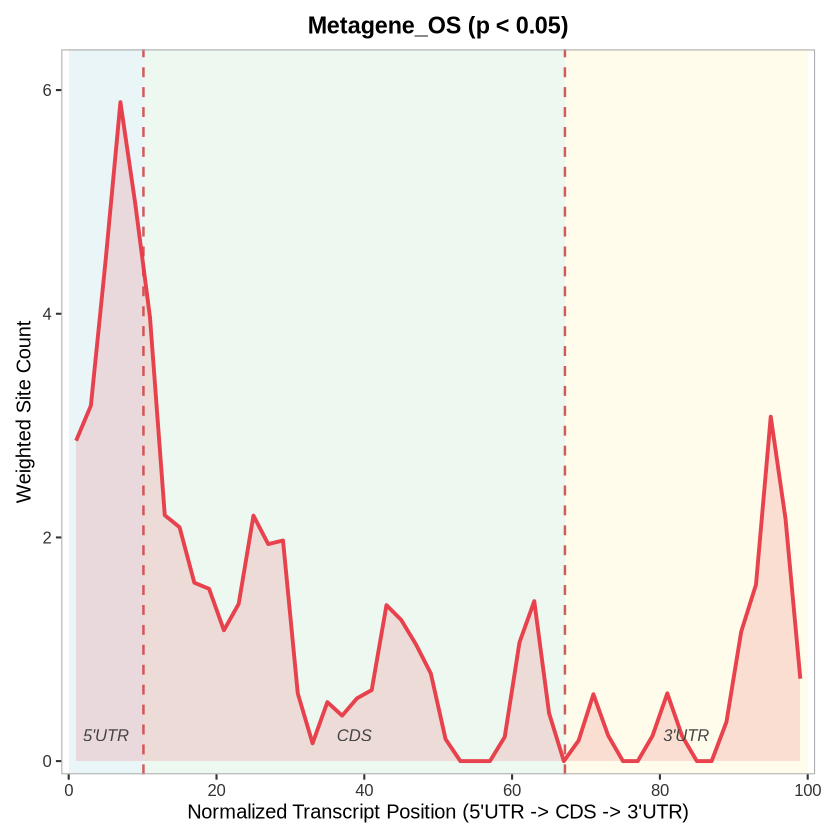

In [24]:
p = plot_metagene(mg_fdr, title = "Metagene_OS (p < 0.05)")

ggsave(
  filename = "/home/tangyh/project/zhanzhouwei/Metagene_OS.pdf",
  plot = p,
  width = 8,
  height = 6
)
p

In [28]:
genome_ewas_PFS <- run_ewas_cox(
  data_df         = data,       # 原始含 depth 的数据框
  meta            = meta,
  covariates      = c("Age", "Gender"),
  depth_threshold = 5,
  n_cores         = 4,
  outcome         = "PFS"
)

数据中共有样本列： 39 个
已自动生成 site_id：chrom_pos_ref_strand 格式
meta 与数据匹配的样本数： 38 
深度过滤后 NA 比例： 31.8 %
Cox 公式： Surv(PFS, PFS_status) ~ meth + Age + Gender 
── EWAS 结果汇总 ──────────────────────
总位点数：            6766 
FDR < 0.05 位点数： 0 
nominal p < 0.05：   445 


In [29]:
mg <- new_metagene_analyzer(
  annotator = annotator,
  sites_df = genome_ewas_PFS,
  n_bins = 50L
)

Initialising MetageneAnalyzer: 6766 sites, 50 bins, strategy = median

Mapping sites to transcript coordinates...



In [30]:
mg_fdr <- calc_metagene_profile(
  mg,
  sig_col = "pval",
  sig_threshold = 0.05,
  sig_op = "<",
  keep_fit_ok = TRUE,
  exclude_or_extreme = TRUE,
  smooth = TRUE,
  span = 0.3
)


Warning message:
“`keep_fit_ok = TRUE` ignored because `fit_ok` is absent.”
Warning message:
“`exclude_or_extreme = TRUE` ignored because `or_extreme` is absent.”
Computing metagene profile (binning + smoothing)...

Done.



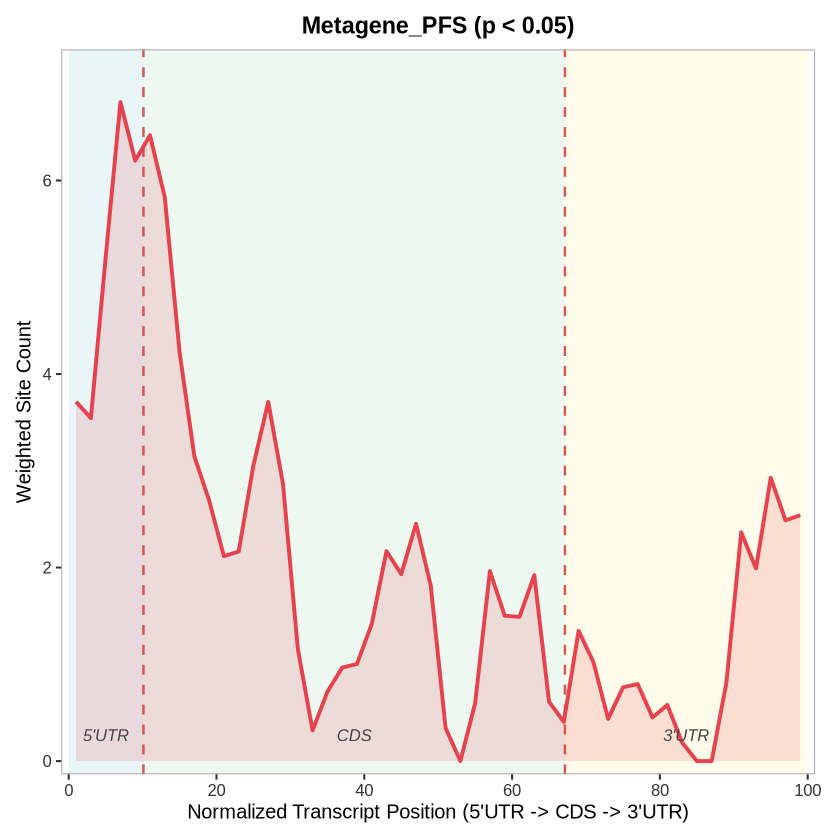

In [31]:
p = plot_metagene(mg_fdr, title = "Metagene_PFS (p < 0.05)")

ggsave(
  filename = "/home/tangyh/project/zhanzhouwei/Metagene_PFS.pdf",
  plot = p,
  width = 8,
  height = 6
)
p